<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Logistic%20Regression/mental_health_ds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adilshamim8/student-depression-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-depression-dataset' dataset.
Path to dataset files: /kaggle/input/student-depression-dataset


In [86]:
import warnings
import pandas as pd

warnings.filterwarnings('ignore')
df = pd.read_csv('/kaggle/input/student-depression-dataset/student_depression_dataset.csv')[:1000]
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     1000 non-null   int64  
 1   Gender                                 1000 non-null   object 
 2   Age                                    1000 non-null   float64
 3   City                                   1000 non-null   object 
 4   Profession                             1000 non-null   object 
 5   Academic Pressure                      1000 non-null   float64
 6   Work Pressure                          1000 non-null   float64
 7   CGPA                                   1000 non-null   float64
 8   Study Satisfaction                     1000 non-null   float64
 9   Job Satisfaction                       1000 non-null   float64
 10  Sleep Duration                         1000 non-null   object 
 11  Dieta

In [89]:
import matplotlib.pyplot as plt

df['Depression'].value_counts()

,count
Depression,
1,589
0,411


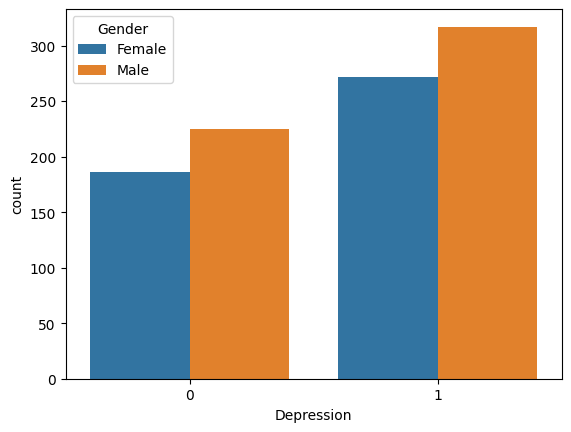

In [98]:
import seaborn as sns

sns.countplot(data=df, x='Depression', hue='Gender')
plt.show()

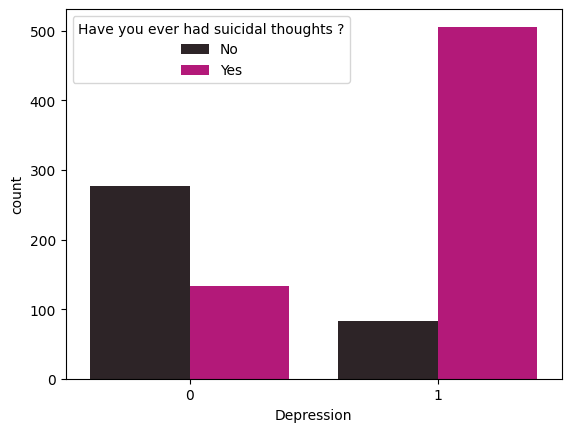

In [103]:
sns.countplot(data=df, x='Depression', hue='Have you ever had suicidal thoughts ?', color=(0.8, 0, 0.5))
plt.show()

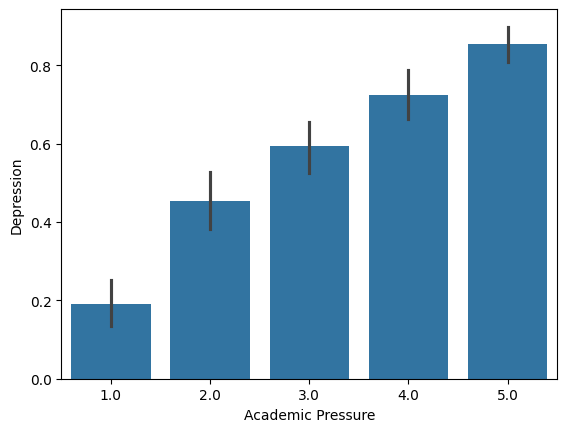

In [108]:
sns.barplot(df, y='Depression', x='Academic Pressure')
plt.show()

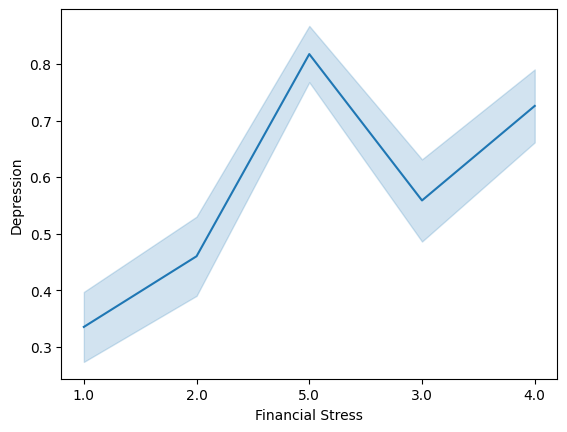

In [117]:
sns.lineplot(df, y='Depression', x='Financial Stress')
plt.show()

In [118]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [120]:
features = pd.DataFrame(df, columns=['Academic Pressure',
       'Work Pressure','Have you ever had suicidal thoughts ?','Financial Stress', 'Family History of Mental Illness'])
features.head()

,Academic Pressure,Work Pressure,Have you ever had suicidal thoughts ?,Financial Stress,Family History of Mental Illness
0,5.0,0.0,Yes,1.0,No
1,2.0,0.0,No,2.0,Yes
2,3.0,0.0,No,1.0,Yes
3,3.0,0.0,Yes,5.0,Yes
4,4.0,0.0,Yes,1.0,No


In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

CT = ColumnTransformer(
    transformers=[
        ('Num', StandardScaler(), ['Academic Pressure','Work Pressure','Financial Stress']),
        ('Cat', OneHotEncoder(), ['Have you ever had suicidal thoughts ?','Family History of Mental Illness'])
    ]
)
features_transformed = CT.fit_transform(features)

In [126]:
transformed_column_names = CT.get_feature_names_out()
pd.DataFrame(features_transformed, columns=transformed_column_names).head()

,Num__Academic Pressure,Num__Work Pressure,Num__Financial Stress,Cat__Have you ever had suicidal thoughts ?_No,Cat__Have you ever had suicidal thoughts ?_Yes,Cat__Family History of Mental Illness_No,Cat__Family History of Mental Illness_Yes
0,1.289238,0.0,-1.428685,0.0,1.0,1.0,0.0
1,-0.826580,0.0,-0.741817,1.0,0.0,0.0,1.0
2,-0.121307,0.0,-1.428685,1.0,0.0,0.0,1.0
3,-0.121307,0.0,1.318786,0.0,1.0,0.0,1.0
4,0.583966,0.0,-1.428685,0.0,1.0,1.0,0.0


In [127]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
label = encoder.fit_transform(df['Depression'])
label

array([1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features_transformed, label, test_size=0.2)

In [129]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [131]:
accuracy = model.score(X_test, y_test)
print(f"Accracy: {accuracy}")

Accracy: 0.83


              precision    recall  f1-score   support

           0       0.97      0.68      0.80        99
           1       0.76      0.98      0.85       101

    accuracy                           0.83       200
   macro avg       0.86      0.83      0.83       200
weighted avg       0.86      0.83      0.83       200



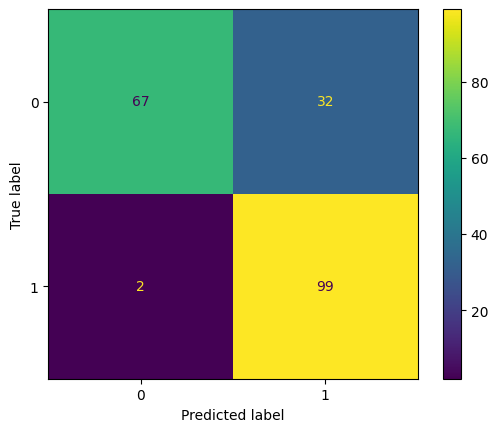

In [134]:
from sklearn.metrics import  confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = model.predict(X_test)
cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
print(cr)